## Preamble

In [6]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

In [7]:
vp=3000
vs=0.
rho=2500

nz=241; nx=241; h=5
nzsnap=289; nxsnap=289; nsnap=51

fpeak=15

dt=0.0004
nt=2500
t=np.arange(0,nt*dt,dt)-0.067

nr=1

In [8]:
!makevel nx=$nx nz=$nz v000=$vp > vp
!makevel nx=$nx nz=$nz v000=$vs > vs
!makevel nx=$nx nz=$nz v000=$rho> rho
!cat vp vs rho > model

In [9]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(nr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [10]:
!cat setup_default2

MODEL_SIZE              '241   241   1'
MODEL_SPACING           '5     5     1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'vp vs rho'

ACQUI_GEOMETRY          spread
FS                      ' 0   100 0'
FR                      '30  1100 0'
DR                      ' 0     0 0'
NR                       1

SCOMP                    vx
RCOMP                   'vz vx p'

NT           2500
DT           0.0004
WAVELET_TYPE ricker
FPEAK        15

SNAPSHOT     'vz vx szz sxx szx'

IF_USE_CHECKPOINT   F


#why the vz comp of dsyn is weird?


## Test vforce
Robertsson, Fig 1,2

### No FS

In [18]:
# PSV modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP         p" >> setup
!echo "SNAPSHOT     'szz sxx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759056 Nov  3 10:33 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 3aabe74
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/03/2025
System time: 10:33:52
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   

In [22]:
# AC modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP         p" >> setup
!echo "SNAPSHOT     'p'" >> setup
!echo "DIR_OUT       res_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 767160 Nov  3 10:40 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 3aabe74
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/03/2025
System time: 10:40:58
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC
 Output directory:res_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.60

In [25]:
# AC2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP         p" >> setup
!echo "SNAPSHOT     'p'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 725056 Nov  3 10:45 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: 3aabe74
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/03/2025
System time: 10:46:21
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

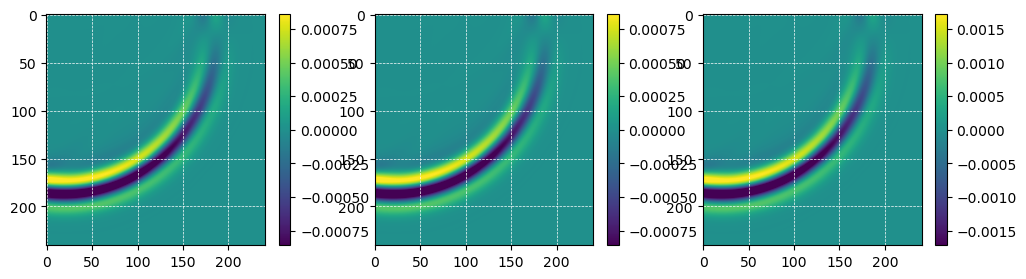

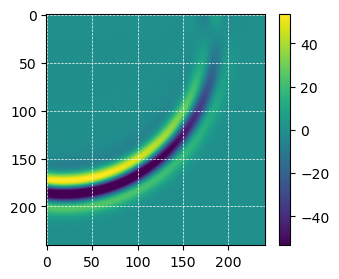

In [23]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV/snap_fld_reU%szz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV/snap_fld_reU%sxx'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_PSV/snap_fld_reU%szz')+read_snap('res_PSV/snap_fld_reU%sxx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%p'),perc=98)

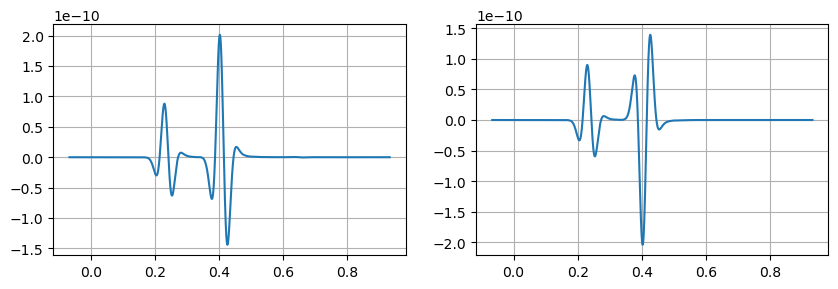

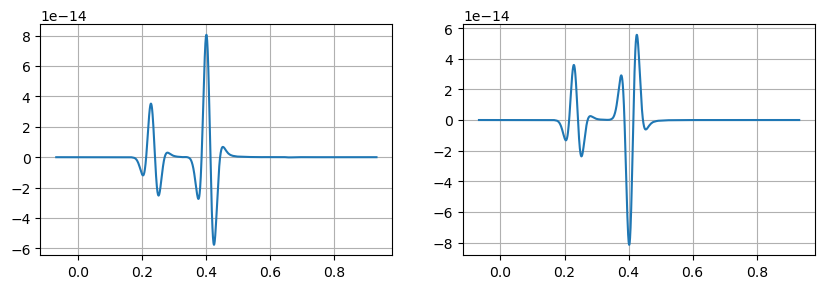

In [85]:
trs=read_su('res_VS/Ru_Shot0001.su',n=(2,nt))

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt))

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,np.gradient(trs[:,0])); plt.grid()
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs[:,1])); plt.grid()

Good match!

### w/ FS

In [60]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         vz" >> setup
!echo "RCOMP        'vz vx'" >> setup
!echo "SNAPSHOT     'vz vx'" >> setup
!echo "DIR_OUT     res_VS" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 552968 Oct 18  2024 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 37e8fa6
 Git Branch: DAS
 Compiler: gfortran v13.2.0
 Version: 13.2.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:24:43
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_VS
 Output directory:res_VS/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606 *Vm

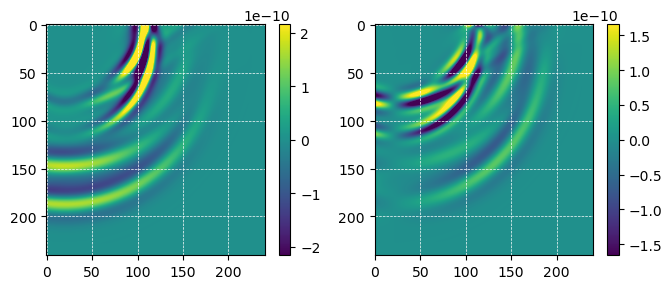

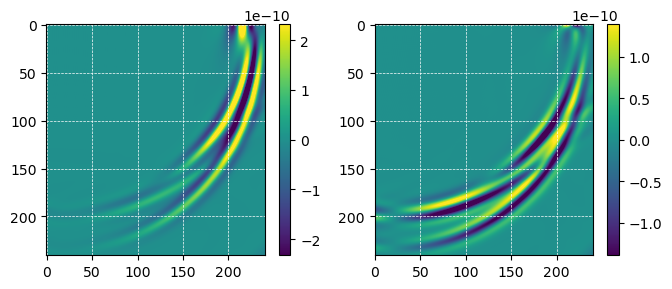

In [61]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx',i=34),perc=98)

In [69]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         uz" >> setup
!echo "RCOMP        'uz ux'" >> setup
!echo "SNAPSHOT     'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 758408 Oct 30 18:32 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: d719e67
 Git Branch: grad_extd_VDSR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:33:07
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

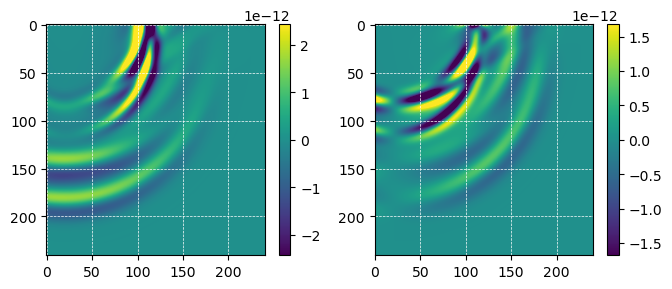

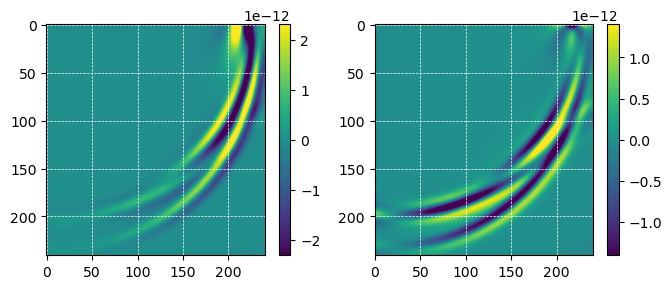

In [70]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux',i=34),perc=98)

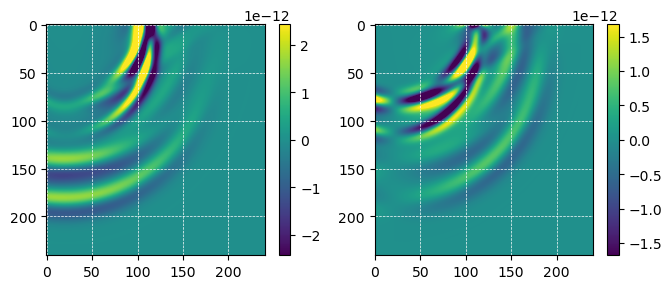

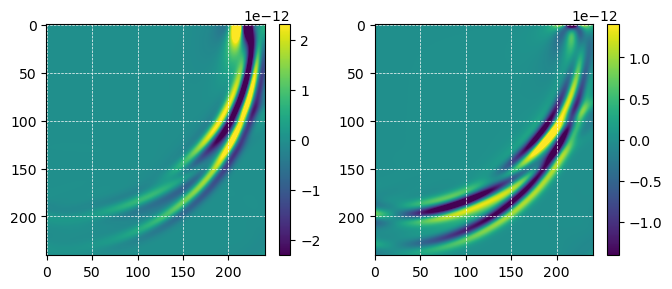

In [63]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux',i=34),perc=98)

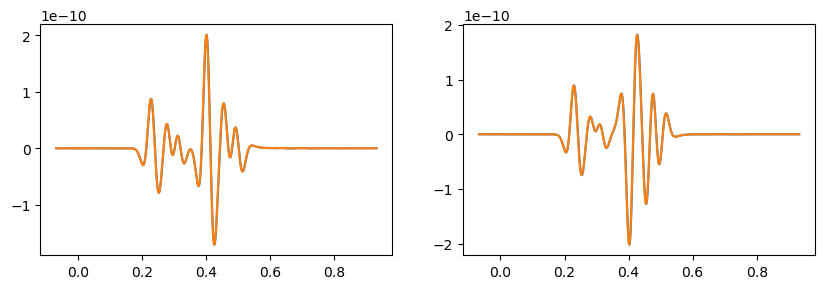

In [72]:
trs1=read_su('res_VS/Ru_Shot0001.su',n=(2,nt))
trs2=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt))

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs1[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs1[:,1]); plt.grid()

plt.subplot(1,2,1); plt.plot(t,np.gradient(trs2[:,0])/dt); plt.grid()
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs2[:,1])/dt); plt.grid()

Good match!

## Test hforce
Robertsson, Fig 1,2

In [73]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         vx" >> setup
!echo "RCOMP        'vz vx'" >> setup
!echo "SNAPSHOT     'vz vx'" >> setup
!echo "DIR_OUT     res_VS" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 552968 Oct 18  2024 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 37e8fa6
 Git Branch: DAS
 Compiler: gfortran v13.2.0
 Version: 13.2.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:34:11
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_VS
 Output directory:res_VS/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606 *Vm

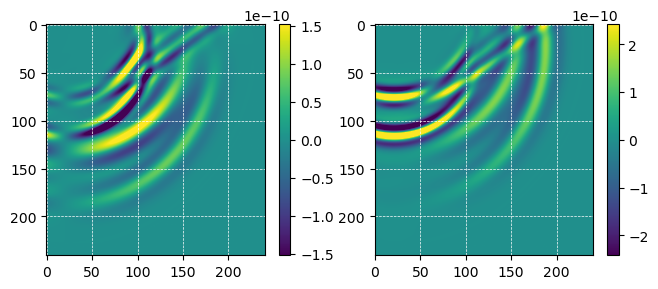

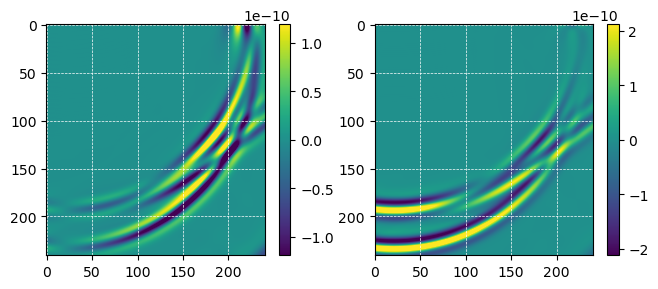

In [74]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx',i=34),perc=98)

In [75]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         ux" >> setup
!echo "RCOMP        'uz ux'" >> setup
!echo "SNAPSHOT     'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 758408 Oct 30 18:32 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: d719e67
 Git Branch: grad_extd_VDSR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:34:15
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

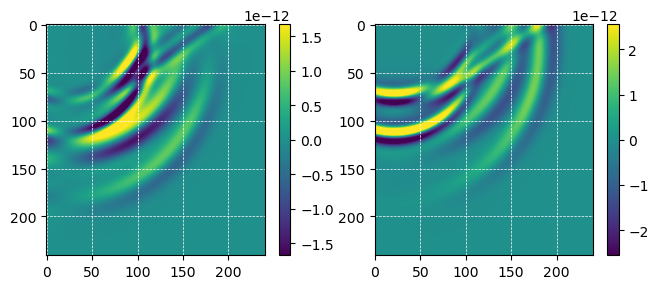

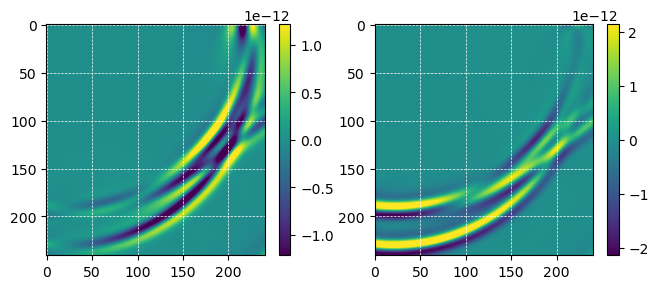

In [77]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux',i=34),perc=98)

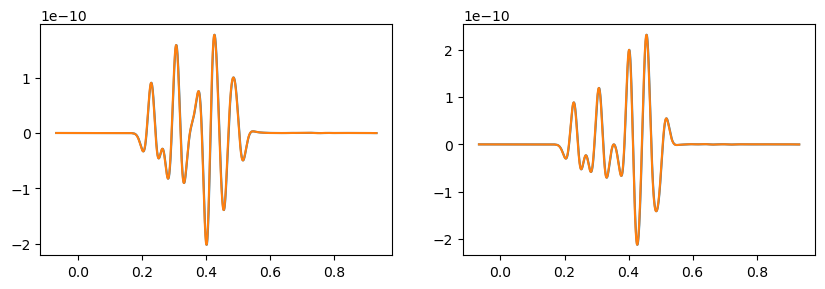

In [78]:
trs1=read_su('res_VS/Ru_Shot0001.su',n=(2,nt))
trs2=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt))

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs1[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs1[:,1]); plt.grid()

plt.subplot(1,2,1); plt.plot(t,np.gradient(trs2[:,0])/dt); plt.grid()
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs2[:,1])/dt); plt.grid()

Good match!

## acqui close to FS
Robertsson, Fig 1,2

### Test vforce

In [85]:
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP         vz" >> setup
!echo "RCOMP        'vz vx'" >> setup
!echo "SNAPSHOT     'vz vx'" >> setup
!echo "DIR_OUT     res_VS" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 552968 Oct 18  2024 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 37e8fa6
 Git Branch: DAS
 Compiler: gfortran v13.2.0
 Version: 13.2.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:41:49
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_VS
 Output directory:res_VS/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606 *Vm

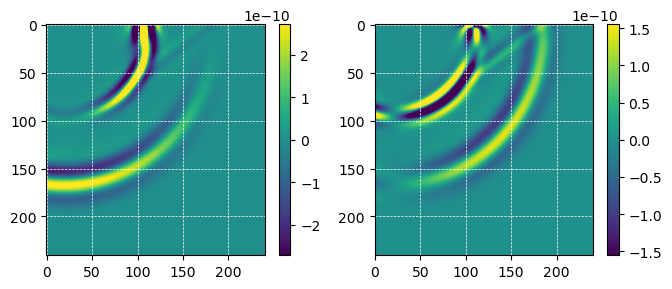

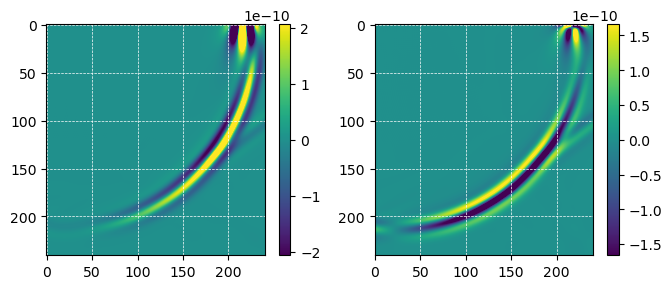

In [86]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx',i=34),perc=98)

In [87]:
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP         uz" >> setup
!echo "RCOMP        'uz ux'" >> setup
!echo "SNAPSHOT     'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 758408 Oct 30 18:32 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: d719e67
 Git Branch: grad_extd_VDSR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:41:56
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

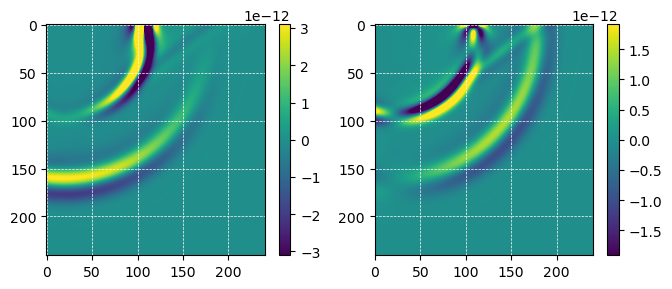

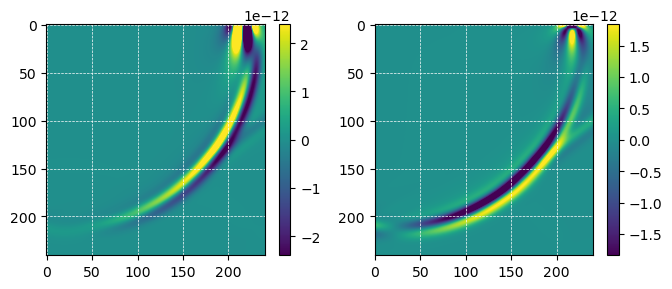

In [88]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux',i=34),perc=98)

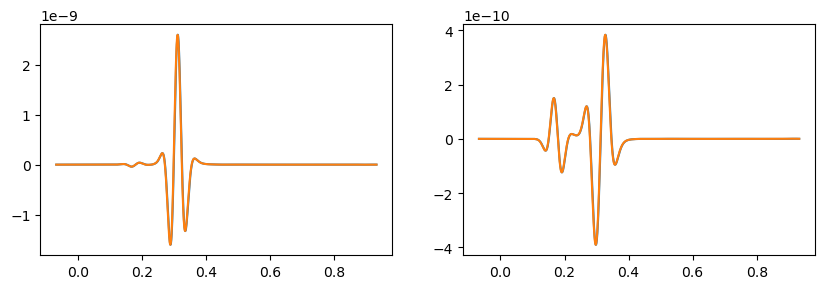

In [89]:
trs1=read_su('res_VS/Ru_Shot0001.su',n=(2,nt))
trs2=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt))

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs1[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs1[:,1]); plt.grid()

plt.subplot(1,2,1); plt.plot(t,np.gradient(trs2[:,0])/dt); plt.grid()
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs2[:,1])/dt); plt.grid()

Good match!

### Test hforce

In [90]:
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP         vx" >> setup
!echo "RCOMP        'vz vx'" >> setup
!echo "SNAPSHOT     'vz vx'" >> setup
!echo "DIR_OUT     res_VS" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 552968 Oct 18  2024 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 37e8fa6
 Git Branch: DAS
 Compiler: gfortran v13.2.0
 Version: 13.2.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:42:28
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_VS
 Output directory:res_VS/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606 *Vm

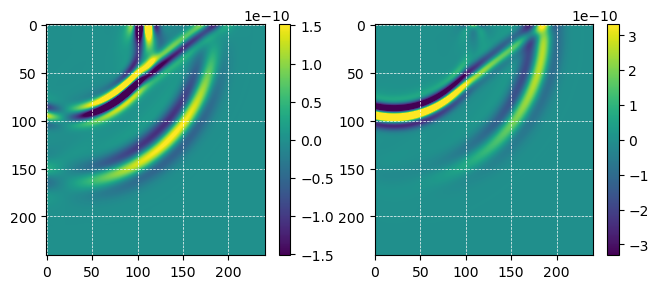

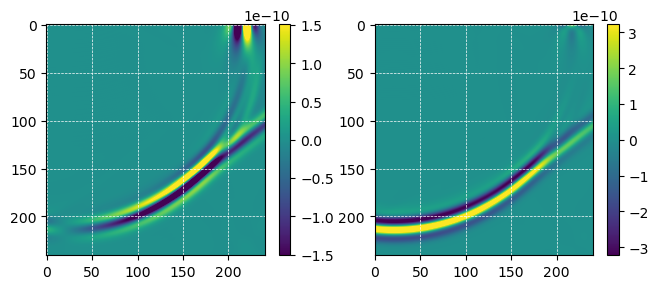

In [91]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_VS/snap_fld_u%vz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_VS/snap_fld_u%vx',i=34),perc=98)

In [92]:
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP         ux" >> setup
!echo "RCOMP        'uz ux'" >> setup
!echo "SNAPSHOT     'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 758408 Oct 30 18:32 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: d719e67
 Git Branch: grad_extd_VDSR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 10/30/2025
System time: 18:42:35
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

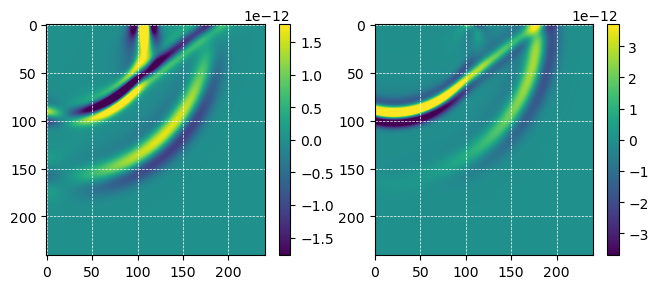

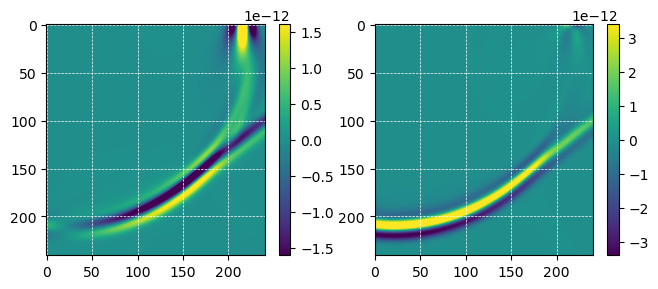

In [93]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_u%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_u%ux',i=34),perc=98)

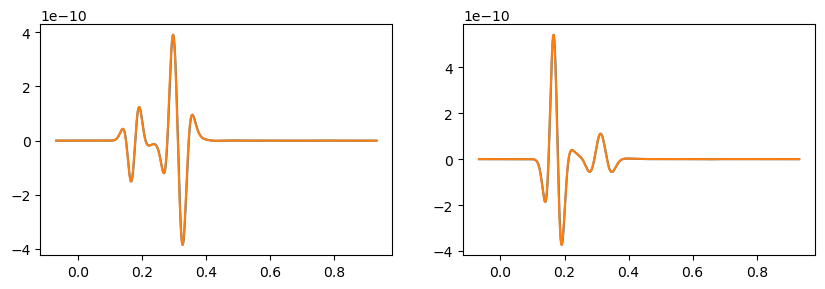

In [94]:
trs1=read_su('res_VS/Ru_Shot0001.su',n=(2,nt))
trs2=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt))

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs1[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs1[:,1]); plt.grid()

plt.subplot(1,2,1); plt.plot(t,np.gradient(trs2[:,0])/dt); plt.grid()
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs2[:,1])/dt); plt.grid()

Good match!